# Populasjonsvekst -- skandinavia

In [1]:
import math
land = ["Norge", "Sverige", "Danmark"]
K = [20e6, 25e6, 15e6] #Makspopulasjon
r = [0.01, 0.02, 0.03] #relativ vekstrate
P0 = [4e6, 8e6, 6e6] # Startpopulasjon
t = 20 #Hvor mange år vekst


def logistisk_vekst(P0,K,r,t):
    A = (K-P0)/P0
    P = K/(1+A*math.exp(-r*t))
    return P
  
def lag_pop_funk(P0,K,r):
    def slutt_populasjon(t):
        P = logistisk_vekst(P0,K,r,t)
        return P
    return slutt_populasjon #Vi returnerer funksjonen vi laget inne i funksjonen!

def format_pop(P):
    return int(round(P,-3))

pop_funksjoner = [] #Liste med funksjoner som regner ut populasjon ved tiden t for land 0,1,2
pop_funksjoner.append( lag_pop_funk(P0[0], K[0], r[0]))
pop_funksjoner.append(lag_pop_funk(P0[1], K[1], r[1]))
pop_funksjoner.append(lag_pop_funk(P0[2], K[2], r[2]))
#Vi kunne også lagret disse funksjonene i en liste.. :)

#print(type(pop_norge))
P_slutt = []
P_slutt.append(pop_funksjoner[0](t))
P_slutt.append(pop_funksjoner[1](t))
P_slutt.append(pop_funksjoner[2](t))

print("Sluttpopulasjonen i", land[0], "er:", format_pop(P_slutt[0]))
print("Sluttpopulasjonen i", land[1], "er:", format_pop(P_slutt[1]))
print("Sluttpopulasjonen i", land[2], "er:", format_pop(P_slutt[2]))


Sluttpopulasjonen i Norge er: 4678000
Sluttpopulasjonen i Sverige er: 10312000
Sluttpopulasjonen i Danmark er: 8227000


Sluttpopulasjonen i  Norge er etter 20 år: 4640000
Sluttpopulasjonen i  Sverige er etter 20 år: 10190000
Sluttpopulasjonen i  Danmark er etter 20 år: 8120000


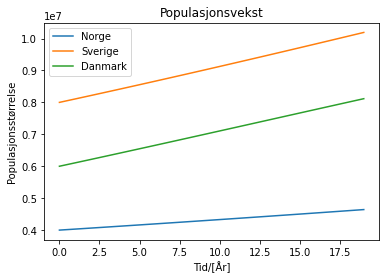

In [2]:
import math
import matplotlib.pyplot as plt
land = ["Norge", "Sverige", "Danmark"]
K = [20e6, 25e6, 15e6] #Makspopulasjon
r = [0.01, 0.02, 0.03] #relativ vekstrate
P0 = [4e6, 8e6, 6e6] # Startpopulasjon
t = 20 #Hvor mange år vekst


def logistisk_vekst(P0,K,r,t):
    A = (K-P0)/P0
    P = K/(1+A*math.exp(-r*t))
    return P

pop_vekst_liste = []
n_land = len(land)
for i in range(n_land):
    pop_vekst = []
    for aar in range(t):
        populasjon = logistisk_vekst(P0[i], K[i], r[i], aar)
        pop_vekst.append(populasjon)
    pop_vekst_liste.append(pop_vekst)


plt.title("Populasjonsvekst")
plt.xlabel("Tid/[År]")
plt.ylabel("Populasjonsstørrelse")

for i,l in enumerate(land):
    print("Sluttpopulasjonen i ", l, "er etter", t, "år:", int(round(pop_vekst_liste[i][-1], -4)))
    plt.plot(list(range(t)), pop_vekst_liste[i], label=l)
plt.legend()
plt.show()

#pop_norge = lambda t: logistisk_vekst(P0[0], K[0], r[0], t)
#pop_norge(200)




# Oppg.
* I eksempelet over er dataene spredt utover flere variabler
* Ofte er det bedre å «pakke» den litt mer sammen
* Prøv å regne ut og plotte populasjonsveksten slik som over, men pakk sammen dataen først:

- Lag en variabler `data` som er en liste av lister som ser omtrent slik ut:
```python
[
    ['Norge', 4000000.0, 20000000.0, 0.01], 
    ['Sverige', 8000000.0, 25000000.0, 0.02], 
    ['Danmark', 6000000.0, 15000000.0, 0.03]
]
```
- Bruk en `for` løkke til å sette dette sammen (Skriv ikke inn for hånd)
  

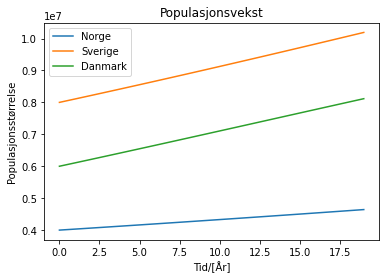

In [3]:


data = []
#Iterer over indeksen til dataene våre (0,1,2) og sett sammen "datalisten"
for i in range(len(land)):
    datapunkt = [land[i], P0[i], K[i], r[i]]
    #vekst_funksjon = lambda t: logistisk_vekst(P0[0], K[0], r[0], t) # Kjapp måte å lage en funksjon på (eks fx = lambda x: 2x-x**2)
    #datapunkt.append(vekst_funksjon)
    data.append(datapunkt)

t_liste = list(range(t))
#Iterer over dataene og regn ut populasjonsvekstlisten, og legg de til bakerst i "datapunktene"
#Du trenger to løkker -- først over dataene -- deretter over årene
for d in data:
    pop_vekst = []
    for ti in t_liste:
        #populasjon = d[4](ti)
        populasjon = logistisk_vekst(d[1], d[2],d[3], ti)
        pop_vekst.append(populasjon)
    d.append(pop_vekst)

plt.title("Populasjonsvekst")
plt.xlabel("Tid/[År]")
plt.ylabel("Populasjonsstørrelse")

for d in data:
    plt.plot(t_liste, d[-1], label=d[0])
plt.legend()
plt.show()

    

# Kontrollflyt: (Boolsk aritmetikk og if-else)
![hei](https://www.c-sharpcorner.com/UploadFile/BlogImages/06212022091850AM/COntrol.png)

# Kontrollflyt
* Vi trenger en måte å kontrolle hva av koden vår som blir kjørt i ulike situasjoner
* Vi trenger kanskje å kjøre forskjellig kode om det oppstår en feil i koden vår
* Vi trenger at koden vår gjør valg og kjører forskjellig kode ved forskjellig data
* I Python kan vi bruke `if` `else` og `elif`

In [6]:
def er_myndig(alder):
    if alder < 18:
        print("Du er ikke myndig")
    else:
        print("Du er myndig")

alder = int(input("Hva er din alder?"))
er_myndig(alder)


Hva er din alder? 25


Du er myndig


```python
if «boolsk verdi eller uttrykk»:
    #Blokk med kode dersom True
else:
    #Blokk med kode dersom False
```
* Boolsk verdier er en datatype som har verdien `True` eller `False`
* Et boolsk uttrykk får en av disse verdiene når vi evaluerer de
* Boolske uttrykk er bygd av boolske "operatorer"

# Boolske operatorer
| Operator | Beskrivelse                                   | Eksempel               | Resultat    |
|----------|----------------------------------------------|------------------------|-------------|
| `and`    | Returnerer `True` hvis begge påstandene er sanne | `True and False`    | `False`     |
| `or`     | Returnerer `True` hvis én av påstandene er sann | `True or False`     | `True`      |
| `not`    | Reverserer den boolske verdien                | `not True`             | `False`     |
| `==`     | Sjekker om to verdier er like                 | `5 == 5`               | `True`      |
| `!=`     | Sjekker om to verdier ikke er like            | `5 != 3`               | `True`      |
| `>`      | Sjekker om venstre verdi er større enn høyre  | `5 > 3`                | `True`      |
| `<`      | Sjekker om venstre verdi er mindre enn høyre  | `5 < 3`                | `False`     |
| `>=`     | Sjekker om venstre verdi er større enn eller lik høyre | `5 >= 5` | `True`      |
| `<=`     | Sjekker om venstre verdi er mindre enn eller lik høyre  | `3 <= 5` | `True`      |


# Eksempler:

In [23]:
tall = 10
if tall == 10:
    print("tallet er 10")

tallet er 10


In [25]:
if tall != 11:
    print("tallet er ikke 11")
else:
    print("tallet er 11")

tallet er ikke 11


In [12]:
det_regner = True
det_er_kaldt = False

if det_regner and det_er_kaldt:
    print("Bli inne")
else:
    print("Ta deg en tur :)")


Ta deg en tur :)
Bli inne...
ta med paraply


In [18]:
if det_regner or det_er_kaldt:
    print("Bli inne...")
else:
    print("Ta deg en tur ut")

Bli inne...


In [20]:
if not det_regner:
    print("Stikk ut :)")
else:
    print("ta med paraply")

if det_regner != False:
    print("det regner")
else:
    print("det regner ikke")

ta med paraply
det regner


* Vi må ikke bruke `else` blokken


In [28]:
if tall >= 10:
    print("større enn 10")

større enn 10


* `elif` lar oss gjøre en ny sjekk i stedet for `else`

In [31]:
if not det_regner:
    print("det regner")
elif det_er_kaldt:
    print("Det er kaldt")
else:
    print("Ta deg en tur ut :)")

Ta deg en tur ut :)


# Løkker: While
* While løkken lar oss loope/iterere så lenge et boolsk uttrykk er «True»
```python
while «boolsk uttrykk»:
    #Løkke
    #Løkke
#løkke ferdig
```

Hva er ønsket terminbelop? 1000


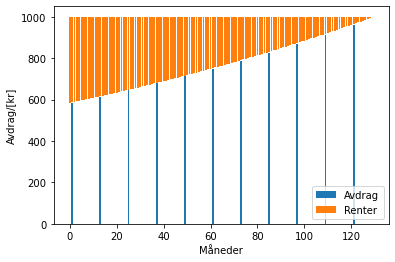

Nedbetalingstiden på  10 år og 10 måneder er for lang


In [3]:
# Annuitetslån
import matplotlib.pyplot as plt

laan = 100000
rentesats = 0.05
terminbelop = float(input("Hva er ønsket terminbelop?"))
renter = laan*rentesats/12
max_nedbetalingstid = 10

def sjekk_terminbelop():
    if terminbelop < renter:
        print("Terminbeløpet er for lite til å dekke rentene av lånet")
        print("Renter ved første termin er ", renter)
        return False
    else:
        return True

if sjekk_terminbelop():
    
    renter_liste = []
    avdrag_liste = []
    
    laan_rest = laan
    mnd = 0
    while laan_rest > 0:
        renter = laan_rest*rentesats/12
        avdrag = terminbelop - renter
        renter_liste.append(renter)
        avdrag_liste.append(avdrag)
        laan_rest -= avdrag
        mnd += 1
    
    plt.bar(list(range(1,mnd,12)), avdrag_liste[::12], label="Avdrag")
    plt.bar(list(range(mnd)), renter_liste, bottom=avdrag_liste, label="Renter")
    plt.xlabel("Måneder")
    plt.ylabel("Avdrag/[kr]")
    plt.legend()
    plt.show()
    #Plot ser ikke bra ut ennå...
    if mnd/12 > max_nedbetalingstid:
        print("Nedbetalingstiden på ", mnd//12, "år og", mnd%12, "måneder er for lang")
else:
    print("Avbryter låneutregning")
    


